# claude-opus-4-8 — KV(프롬프트) 캐시 벤치마크

**대상 모델**: `claude-opus-4-8`
**측정 항목**: 캐시 미사용 / 캐시 쓰기 / 캐시 읽기 3상태의 **TTFT**, **전체 latency**, **캐시 토큰**, **비용**

## Anthropic 캐싱 메커니즘 — OpenAI 와 결정적으로 다른 점

| | OpenAI (GPT) | Anthropic (Claude) |
|---|---|---|
| 켜는 방식 | **자동** (1024 토큰 넘으면 알아서) | **명시적** — `cache_control` 을 직접 찍어야 함 |
| 캐시 지점 | 프리픽스 전체 자동 | `cache_control` **블록까지**가 캐시 대상 (최대 4개 지점) |
| 쓰기 비용 | 없음 (일반 입력가) | **1.25배** (5분 TTL) / 2배 (1시간 TTL) |
| 읽기 비용 | 입력가의 ~10% | 입력가의 **10%** |
| usage 필드 | `cached_tokens` | `cache_creation_input_tokens` / `cache_read_input_tokens` |

- 프리픽스 렌더링 순서는 **`tools` → `system` → `messages`**. `cache_control` 지점까지의 바이트가 정확히 같아야 히트합니다.
- 쓰기에 1.25배를 먼저 내므로, **같은 프리픽스를 2회 이상 재사용해야 본전**입니다 (1회성 요청엔 손해).

## 실험 설계 — 3상태 비교
1. **NOCACHE** — `cache_control` 없이 호출. 캐싱을 아예 안 쓰는 baseline (입력 1배).
2. **WRITE** — `cache_control` + 매번 유니크 nonce → 매 호출 새 캐시 생성 (입력 1.25배). *캐시 미스의 최악 케이스*.
3. **READ** — `cache_control` + 동일 프리픽스 반복 → 캐시 적중 (입력 0.1배).

> ⚠️ 기본 TTL 은 **5분**이며 요청이 있을 때마다 갱신됩니다. 셀을 띄엄띄엄 실행하면 evict 될 수 있으니 **연속 실행**하세요.


In [1]:
# === 셋업 & 실험 설정 ===
import json, os, pathlib, statistics, time, uuid

import anthropic

try:
    from dotenv import load_dotenv
    load_dotenv()  # 프로젝트 루트 .env 의 ANTHROPIC_API_KEY 로드
except Exception:
    pass

assert os.environ.get("ANTHROPIC_API_KEY"), ".env 에 ANTHROPIC_API_KEY 를 설정해주세요"
client = anthropic.Anthropic()

# ------- 조절 가능한 설정 -------
MODEL             = "claude-opus-4-8"
TARGET_TOKENS     = 20_000     # 캐시할 프리픽스(문서) 목표 크기
MAX_OUTPUT_TOKENS = 32         # 출력 짧게 고정 → prefill 캐싱 효과에 집중
N_REPEAT          = 3          # 각 상태별 반복 횟수
N_WARMUP          = 1          # 캐시 적재용 워밍업 (WRITE 1회)

# ------- 단가 ($ / 1M tokens) -------
# ⚠️ 입력가는 기존 notebooks/claude/claude_prompt_caching.ipynb 기준값입니다.
#    출력가는 미확인 플레이스홀더이므로 Anthropic 공식 pricing 으로 교체하세요.
PRICE_INPUT  = 5.00
PRICE_OUTPUT = 25.00   # ⚠️ 미확인 — 플레이스홀더
CACHE_WRITE_MULT = 1.25   # 5분 TTL 쓰기 배수
CACHE_READ_MULT  = 0.10   # 읽기 배수


def calc_cost(usage):
    """usage 3필드(일반입력/캐시쓰기/캐시읽기) + 출력으로 실제 과금액 계산."""
    return (
        usage.input_tokens * PRICE_INPUT
        + usage.cache_creation_input_tokens * PRICE_INPUT * CACHE_WRITE_MULT
        + usage.cache_read_input_tokens * PRICE_INPUT * CACHE_READ_MULT
        + usage.output_tokens * PRICE_OUTPUT
    ) / 1_000_000


print(f"모델: {MODEL} | 목표 토큰: {TARGET_TOKENS:,} | 반복: {N_REPEAT} | 출력한도: {MAX_OUTPUT_TOKENS}")
print(f"단가($/1M): in {PRICE_INPUT} | out {PRICE_OUTPUT} | write x{CACHE_WRITE_MULT} | read x{CACHE_READ_MULT}")

모델: claude-opus-4-8 | 목표 토큰: 20,000 | 반복: 3 | 출력한도: 32
단가($/1M): in 5.0 | out 25.0 | write x1.25 | read x0.1


In [2]:
# === 캐시할 대용량 프리픽스 생성 (합성 운영 매뉴얼) ===
TOPICS = [
    "가상 머신 프로비저닝", "오토스케일링 정책", "로드밸런서 구성", "방화벽 규칙 관리",
    "객체 스토리지 수명주기", "블록 스토리지 스냅샷", "데이터베이스 백업", "읽기 전용 복제본",
    "VPC 네트워크 설계", "서브넷 분리 전략", "NAT 게이트웨이 운영", "프라이빗 엔드포인트",
    "IAM 역할 설계", "최소 권한 원칙", "감사 로그 보존", "비밀 키 로테이션",
    "모니터링 지표 수집", "알림 임계값 설정", "장애 대응 절차", "온콜 에스컬레이션",
    "배포 파이프라인", "블루그린 배포", "카나리 릴리스", "롤백 전략",
    "컨테이너 레지스트리", "쿠버네티스 노드풀", "파드 리소스 제한", "헬름 차트 관리",
    "비용 최적화 리뷰", "예약 인스턴스 정책", "미사용 리소스 정리", "태깅 표준",
    "재해 복구 계획", "다중 리전 이중화", "RTO/RPO 목표", "복구 훈련 절차",
    "규정 준수 점검", "데이터 암호화 표준", "접근 기록 검토", "보안 패치 주기",
]


def make_section(i, topic, pad=1):
    body = (
        f"{topic} 업무는 운영팀의 핵심 책임 영역이다. 담당자는 매 분기 초에 {topic} 관련 설정을 전수 점검하고, "
        f"변경이 필요한 항목은 변경관리위원회(CAB)의 승인을 받아 계획된 유지보수 window 에만 적용한다. "
        f"{topic}의 표준 절차는 다음과 같다. 첫째, 현재 상태를 스냅샷으로 기록해 변경 전후 비교가 가능하게 한다. "
        f"둘째, 스테이징에서 동일 변경을 선반영하고 회귀 테스트를 통과시킨다. 셋째, 운영 반영은 4-eyes 원칙에 따라 "
        f"두 명 이상이 확인한다. 넷째, 반영 후 30분간 지표를 관찰하고 이상 시 즉시 롤백한다. "
        f"P1 등급 장애 발생 시 초동 대응은 15분 이내, RCA 보고서는 영업일 기준 3일 이내에 제출한다. "
    ) * pad
    return f"## 제{i}장 {topic}\n{body}\n"


def build_doc(target_tokens):
    """count_tokens 로 실측하며 목표 토큰에 근접할 때까지 섹션을 반복 적재."""
    pad, doc = 1, ""
    while True:
        doc = "\n".join(make_section(i, t, pad) for i, t in enumerate(TOPICS, start=1))
        n = client.messages.count_tokens(
            model=MODEL, system=doc, messages=[{"role": "user", "content": "확인용"}]
        ).input_tokens
        if n >= target_tokens or pad > 40:
            return doc, n
        pad += 1


LARGE_DOC, DOC_TOKENS = build_doc(TARGET_TOKENS)
print(f"프리픽스 문서 실측 토큰: {DOC_TOKENS:,} (목표 {TARGET_TOKENS:,})")

SYSTEM_TEXT = "당신은 사내 클라우드 운영 매뉴얼 전문 어시스턴트입니다. 아래 매뉴얼에 근거해서만 답변하세요.\n\n" + LARGE_DOC
QUESTION = "P1 등급 장애의 초동 대응 시간과 RCA 제출 기한은? 한 문장으로."

프리픽스 문서 실측 토큰: 30,518 (목표 20,000)


In [3]:
# === 최소 캐싱 크기 실측 ===
# 문서상 "Opus 계열은 1024 토큰 이상" 이지만, 실제로 어디서부터 캐싱이 걸리는지 직접 확인합니다.
# 임계 미만이면 에러 없이 "조용히" 캐싱되지 않는 것이 핵심 함정입니다.
def probe_min_cacheable(approx_tokens):
    """approx_tokens 크기 프리픽스로 write→read 를 시도하고 캐시 동작 여부를 반환."""
    unit = "운영 매뉴얼 점검 항목이다. 담당자는 분기마다 설정을 전수 점검한다. "
    doc = unit * max(1, approx_tokens // 20)
    blocks = [{"type": "text", "text": "운영 도우미.\n\n" + doc,
               "cache_control": {"type": "ephemeral"}}]
    n = client.messages.count_tokens(model=MODEL, system=blocks,
                                     messages=[{"role": "user", "content": "hi"}]).input_tokens
    kw = dict(model=MODEL, max_tokens=8, system=blocks,
              messages=[{"role": "user", "content": "ok 이라고만 답해"}])
    u1 = client.messages.create(**kw).usage
    u2 = client.messages.create(**kw).usage
    return n, u1.cache_creation_input_tokens, u2.cache_read_input_tokens


print(f"{'실측토큰':>8} | {'1회차 write':>11} | {'2회차 read':>10} | 캐싱 여부")
print("-" * 52)
MIN_CACHE_PROBE = []
for approx in (400, 900, 1100, 2200):
    n, w, r = probe_min_cacheable(approx)
    ok = "✅ 캐싱됨" if r > 0 else "❌ 캐싱 안 됨"
    MIN_CACHE_PROBE.append({"tokens": n, "write": w, "read": r, "cached": r > 0})
    print(f"{n:>8,} | {w:>11,} | {r:>10,} | {ok}")

_cached = [p["tokens"] for p in MIN_CACHE_PROBE if p["cached"]]
_not = [p["tokens"] for p in MIN_CACHE_PROBE if not p["cached"]]
if _cached and _not:
    print(f"\n→ 최소 캐싱 임계는 {max(_not):,} 초과 ~ {min(_cached):,} 이하 구간에 있습니다 (문서값 1024 와 대조).")
elif _cached:
    print(f"\n→ 시험한 모든 크기({min(_cached):,}~)에서 캐싱됨. 더 작은 크기로 낮춰 임계를 좁혀보세요.")
else:
    print("\n→ 시험한 모든 크기에서 캐싱 안 됨. 더 큰 크기로 올려보세요.")

    실측토큰 |   1회차 write |   2회차 read | 캐싱 여부
----------------------------------------------------


     857 |           0 |          0 | ❌ 캐싱 안 됨


   1,907 |       1,901 |      1,901 | ✅ 캐싱됨


   2,327 |       2,321 |      2,321 | ✅ 캐싱됨


   4,637 |       4,631 |      4,631 | ✅ 캐싱됨

→ 최소 캐싱 임계는 857 초과 ~ 1,907 이하 구간에 있습니다 (문서값 1024 와 대조).


In [4]:
# === 측정 유틸: 스트리밍으로 TTFT + 전체 latency + 캐시 usage ===
def timed_call(mode: str):
    """mode: 'nocache' | 'write' | 'read'
    nocache — cache_control 없음 (baseline, 입력 1배)
    write   — cache_control + 유니크 nonce (매번 새 캐시 생성, 1.25배)
    read    — cache_control + 동일 프리픽스 (캐시 적중, 0.1배)
    """
    text = SYSTEM_TEXT
    if mode == "write":
        # 프리픽스 맨 앞에 nonce → 이전 캐시와 바이트가 달라져 매번 새로 써야 함
        text = f"[nonce-{uuid.uuid4().hex}] " + SYSTEM_TEXT

    block = {"type": "text", "text": text}
    if mode in ("write", "read"):
        block["cache_control"] = {"type": "ephemeral"}

    t0 = time.perf_counter()
    ttft = None
    with client.messages.stream(
        model=MODEL,
        max_tokens=MAX_OUTPUT_TOKENS,
        system=[block],
        messages=[{"role": "user", "content": QUESTION}],
    ) as stream:
        for _ in stream.text_stream:
            if ttft is None:                       # 첫 텍스트 델타 = prefill 종료 근사
                ttft = time.perf_counter() - t0
        msg = stream.get_final_message()
    total = time.perf_counter() - t0
    if ttft is None:
        ttft = total

    u = msg.usage
    return {
        "ttft": ttft, "total": total,
        "input": u.input_tokens,
        "write": u.cache_creation_input_tokens,
        "read": u.cache_read_input_tokens,
        "output": u.output_tokens,
        "cost": calc_cost(u),
    }

In [5]:
# === 워밍업: 캐시 적재 ===
print("워밍업(캐시 쓰기) 중...")
for w in range(max(1, N_WARMUP)):
    r = timed_call("read")   # nonce 없는 프리픽스로 호출 → 최초엔 write, 이후 read
    print(f"  워밍업 {w + 1}: write={r['write']:,} read={r['read']:,} input={r['input']:,} "
          f"TTFT={r['ttft'] * 1000:.0f}ms total={r['total'] * 1000:.0f}ms")
PREFIX_TOKENS = r["write"] + r["read"] + r["input"]
print(f"→ 전체 입력 토큰 {PREFIX_TOKENS:,}")

워밍업(캐시 쓰기) 중...


  워밍업 1: write=30,572 read=0 input=42 TTFT=1271ms total=1852ms
→ 전체 입력 토큰 30,614


In [6]:
# === 벤치마크: NOCACHE / WRITE / READ ===
def bench(mode, n):
    rows = []
    for k in range(n):
        r = timed_call(mode)
        rows.append(r)
        print(f"  [{mode.upper():7s}] {k + 1}/{n}: TTFT={r['ttft'] * 1000:7.0f}ms  total={r['total'] * 1000:7.0f}ms  "
              f"input={r['input']:>7,} write={r['write']:>7,} read={r['read']:>7,}  cost=${r['cost']:.5f}")
    return rows


print("=== NOCACHE (cache_control 없음 — 캐싱 미사용 baseline) ===")
nocache = bench("nocache", N_REPEAT)
print("=== WRITE (매번 새 캐시 생성 — 캐시 미스 최악 케이스) ===")
write = bench("write", N_REPEAT)
print("=== READ (동일 프리픽스 반복 — 캐시 적중) ===")
read = bench("read", N_REPEAT)

=== NOCACHE (cache_control 없음 — 캐싱 미사용 baseline) ===


  [NOCACHE] 1/3: TTFT=   2062ms  total=   2380ms  input= 30,614 write=      0 read=      0  cost=$0.15387


  [NOCACHE] 2/3: TTFT=   1197ms  total=   1694ms  input= 30,614 write=      0 read=      0  cost=$0.15387


  [NOCACHE] 3/3: TTFT=   1176ms  total=   1483ms  input= 30,614 write=      0 read=      0  cost=$0.15387
=== WRITE (매번 새 캐시 생성 — 캐시 미스 최악 케이스) ===


  [WRITE  ] 1/3: TTFT=   1854ms  total=   2195ms  input=     42 write= 30,596 read=      0  cost=$0.19223


  [WRITE  ] 2/3: TTFT=    999ms  total=   1492ms  input=     42 write= 30,602 read=      0  cost=$0.19227


  [WRITE  ] 3/3: TTFT=   1573ms  total=   1943ms  input=     42 write= 30,602 read=      0  cost=$0.19227
=== READ (동일 프리픽스 반복 — 캐시 적중) ===


  [READ   ] 1/3: TTFT=   1920ms  total=   2470ms  input=     42 write=      0 read= 30,572  cost=$0.01630


  [READ   ] 2/3: TTFT=   1597ms  total=   1857ms  input=     42 write=      0 read= 30,572  cost=$0.01630


  [READ   ] 3/3: TTFT=   1260ms  total=   1693ms  input=     42 write=      0 read= 30,572  cost=$0.01630


In [7]:
# === 결과 집계 & 개선율 ===
def stat(rows, key):
    xs = [r[key] for r in rows]
    return {"mean": statistics.mean(xs), "p50": statistics.median(xs), "min": min(xs)}


def ms(x):
    return f"{x * 1000:.0f}"


print(f"모델 {MODEL} | 반복 {N_REPEAT}회 | 입력 {PREFIX_TOKENS:,} tok\n")

summary = {}
for name, key in [("TTFT (첫 토큰)", "ttft"), ("전체 latency", "total")]:
    nc, wr, rd = stat(nocache, key), stat(write, key), stat(read, key)
    imp_nc = (1 - rd["mean"] / nc["mean"]) * 100 if nc["mean"] else 0
    imp_wr = (1 - rd["mean"] / wr["mean"]) * 100 if wr["mean"] else 0
    summary[key] = {"nocache": nc, "write": wr, "read": rd,
                    "improve_vs_nocache_pct": imp_nc, "improve_vs_write_pct": imp_wr}
    print(f"[{name}]")
    print(f"  NOCACHE  mean {ms(nc['mean'])}ms  p50 {ms(nc['p50'])}ms  min {ms(nc['min'])}ms")
    print(f"  WRITE    mean {ms(wr['mean'])}ms  p50 {ms(wr['p50'])}ms  min {ms(wr['min'])}ms")
    print(f"  READ     mean {ms(rd['mean'])}ms  p50 {ms(rd['p50'])}ms  min {ms(rd['min'])}ms")
    print(f"  -> READ 개선: NOCACHE 대비 {imp_nc:5.1f}% / WRITE 대비 {imp_wr:5.1f}% 단축\n")

avg_read = statistics.mean([r["read"] for r in read])
print(f"캐시 읽기 토큰 평균 — READ {avg_read:,.0f} / 전체 {PREFIX_TOKENS:,} "
      f"= 적중률 {avg_read / PREFIX_TOKENS:.1%}")
if avg_read == 0:
    print("⚠️ READ 의 cache_read_input_tokens 가 0 입니다 — TTL(5분) 초과 또는 프리픽스 변경을 의심하세요.")

c_nc = statistics.mean([r["cost"] for r in nocache])
c_wr = statistics.mean([r["cost"] for r in write])
c_rd = statistics.mean([r["cost"] for r in read])
print(f"\n[비용] 호출당 평균 — NOCACHE ${c_nc:.5f} / WRITE ${c_wr:.5f} / READ ${c_rd:.5f}")
print(f"  READ 절감: NOCACHE 대비 {(1 - c_rd / c_nc) * 100:.1f}%")
print(f"  ⚠️ WRITE 는 NOCACHE 보다 {(c_wr / c_nc - 1) * 100:.1f}% 비쌉니다 — 재사용 없는 1회성 요청에 "
      f"cache_control 을 붙이면 순손해입니다.")

breakeven = (CACHE_WRITE_MULT - 1) / (1 - CACHE_READ_MULT)
print(f"  손익분기: 같은 프리픽스를 약 {1 + breakeven:.2f}회 이상 쓰면 이득 "
      f"(쓰기 {CACHE_WRITE_MULT}x 를 읽기 {CACHE_READ_MULT}x 절감분으로 회수)")

모델 claude-opus-4-8 | 반복 3회 | 입력 30,614 tok

[TTFT (첫 토큰)]
  NOCACHE  mean 1478ms  p50 1197ms  min 1176ms
  WRITE    mean 1475ms  p50 1573ms  min 999ms
  READ     mean 1592ms  p50 1597ms  min 1260ms
  -> READ 개선: NOCACHE 대비  -7.7% / WRITE 대비  -7.9% 단축

[전체 latency]
  NOCACHE  mean 1853ms  p50 1694ms  min 1483ms
  WRITE    mean 1877ms  p50 1943ms  min 1492ms
  READ     mean 2007ms  p50 1857ms  min 1693ms
  -> READ 개선: NOCACHE 대비  -8.3% / WRITE 대비  -7.0% 단축

캐시 읽기 토큰 평균 — READ 30,572 / 전체 30,614 = 적중률 99.9%

[비용] 호출당 평균 — NOCACHE $0.15387 / WRITE $0.19226 / READ $0.01630
  READ 절감: NOCACHE 대비 89.4%
  ⚠️ WRITE 는 NOCACHE 보다 24.9% 비쌉니다 — 재사용 없는 1회성 요청에 cache_control 을 붙이면 순손해입니다.
  손익분기: 같은 프리픽스를 약 1.28회 이상 쓰면 이득 (쓰기 1.25x 를 읽기 0.1x 절감분으로 회수)


In [8]:
# === 1시간 TTL 옵션 확인 ===
# 기본 TTL 은 5분(요청마다 갱신). ttl="1h" 로 1시간 유지가 가능하며 쓰기 비용이 2배가 됩니다.
# 여기서는 "1h 쓰기가 실제로 받아들여지는지"만 확인합니다 (1시간 경과 검증은 이 노트북 범위 밖).
try:
    blocks = [{"type": "text",
               "text": "[ttl-1h-probe] " + SYSTEM_TEXT,
               "cache_control": {"type": "ephemeral", "ttl": "1h"}}]
    kw = dict(model=MODEL, max_tokens=8, system=blocks,
              messages=[{"role": "user", "content": QUESTION}])
    u1 = client.messages.create(**kw).usage
    u2 = client.messages.create(**kw).usage
    print(f"1h TTL — 1회차 write={u1.cache_creation_input_tokens:,} / 2회차 read={u2.cache_read_input_tokens:,}")
    detail = getattr(u1, "cache_creation", None)
    if detail is not None:
        print(f"  세부: {detail}")   # ephemeral_5m_input_tokens / ephemeral_1h_input_tokens 분리 리포트
    print("→ 1h TTL 쓰기 수용 확인. 쓰기 단가는 2배(5분은 1.25배)이므로 재사용 간격이 5분을 넘길 때만 이득입니다.")
except Exception as e:
    print("1h TTL 확인 실패(미지원이거나 베타 헤더 필요):", str(e)[:200])

1h TTL — 1회차 write=30,584 / 2회차 read=30,584
  세부: CacheCreation(ephemeral_1h_input_tokens=30584, ephemeral_5m_input_tokens=0)
→ 1h TTL 쓰기 수용 확인. 쓰기 단가는 2배(5분은 1.25배)이므로 재사용 간격이 5분을 넘길 때만 이득입니다.


/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_35806/1633754541.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w9/hg7z_wt94d76808sxt0wm2c80000gn/T/ipykernel_35806/1633754541.py:23: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/user/jinsup_space/research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/user/jinsup_space/research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


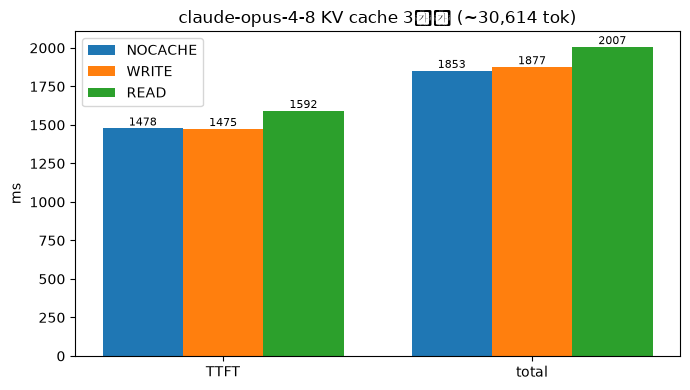

In [9]:
# === 막대그래프 (matplotlib 있으면) ===
try:
    import matplotlib.pyplot as plt

    labels = ["TTFT", "total"]
    series = [
        ("NOCACHE", [summary["ttft"]["nocache"]["mean"] * 1000, summary["total"]["nocache"]["mean"] * 1000]),
        ("WRITE", [summary["ttft"]["write"]["mean"] * 1000, summary["total"]["write"]["mean"] * 1000]),
        ("READ", [summary["ttft"]["read"]["mean"] * 1000, summary["total"]["read"]["mean"] * 1000]),
    ]
    xs, w = range(len(labels)), 0.26
    fig, ax = plt.subplots(figsize=(7, 4))
    for idx, (name, vals) in enumerate(series):
        off = (idx - 1) * w
        ax.bar([x + off for x in xs], vals, w, label=name)
        for i, v in enumerate(vals):
            ax.text(i + off, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("ms")
    ax.set_xticks(list(xs))
    ax.set_xticklabels(labels)
    ax.set_title(f"{MODEL} KV cache 3상태 (~{PREFIX_TOKENS:,} tok)")
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("시각화 건너뜀:", e)

In [10]:
# === 결과 저장 (4개 노트북 공통 스키마 → 교차 비교용) ===
result = {
    "provider": "anthropic",
    "model": MODEL,
    "cache_mode": "explicit-cache_control",
    "target_tokens": TARGET_TOKENS,
    "prompt_tokens": PREFIX_TOKENS,
    "n_repeat": N_REPEAT,
    # 공통 필드에서 miss 는 NOCACHE(캐싱 미사용), hit 은 READ 로 매핑
    "ttft_miss_ms": summary["ttft"]["nocache"]["mean"] * 1000,
    "ttft_hit_ms": summary["ttft"]["read"]["mean"] * 1000,
    "ttft_improve_pct": summary["ttft"]["improve_vs_nocache_pct"],
    "total_miss_ms": summary["total"]["nocache"]["mean"] * 1000,
    "total_hit_ms": summary["total"]["read"]["mean"] * 1000,
    "total_improve_pct": summary["total"]["improve_vs_nocache_pct"],
    "cached_tokens_hit": avg_read,
    "cached_tokens_miss": 0,
    "hit_rate": avg_read / PREFIX_TOKENS if PREFIX_TOKENS else 0,
    "cost_miss_usd": c_nc,
    "cost_hit_usd": c_rd,
    "cost_save_pct": (1 - c_rd / c_nc) * 100 if c_nc else 0,
    # Anthropic 고유 필드
    "anthropic_write_ttft_ms": summary["ttft"]["write"]["mean"] * 1000,
    "anthropic_cost_write_usd": c_wr,
    "anthropic_min_cache_probe": MIN_CACHE_PROBE,
}
out = pathlib.Path("results.json")
out.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장: {out.resolve()}")
print(json.dumps(result, indent=2, ensure_ascii=False))

저장: /Users/user/jinsup_space/research/notebooks/kv_cache/claude_opus48/results.json
{
  "provider": "anthropic",
  "model": "claude-opus-4-8",
  "cache_mode": "explicit-cache_control",
  "target_tokens": 20000,
  "prompt_tokens": 30614,
  "n_repeat": 3,
  "ttft_miss_ms": 1478.432305700456,
  "ttft_hit_ms": 1592.4344443483278,
  "ttft_improve_pct": -7.711015121105569,
  "total_miss_ms": 1852.5129723905895,
  "total_hit_ms": 2007.1170833349847,
  "total_improve_pct": -8.345642554118538,
  "cached_tokens_hit": 30572,
  "cached_tokens_miss": 0,
  "hit_rate": 0.9986280786568237,
  "cost_miss_usd": 0.15387,
  "cost_hit_usd": 0.016296,
  "cost_save_pct": 89.40924156755703,
  "anthropic_write_ttft_ms": 1475.3008746386815,
  "anthropic_cost_write_usd": 0.19226000000000001,
  "anthropic_min_cache_probe": [
    {
      "tokens": 857,
      "write": 0,
      "read": 0,
      "cached": false
    },
    {
      "tokens": 1907,
      "write": 1901,
      "read": 1901,
      "cached": true
    },
    

## 결과 해석 가이드

- **READ 가 NOCACHE 보다 빨라야** 캐싱이 실제로 작동한 것입니다. `cache_read_input_tokens` 가 0 이 아닌지 반드시 확인하세요 — 시간 수치보다 이 필드가 정확한 지표입니다.
- **WRITE 가 NOCACHE 보다 느리고 비싼 것이 정상**입니다. 캐시를 만드는 오버헤드(1.25배 과금)를 내는 상태이기 때문입니다. 이 상태가 반복되면 캐싱을 쓰는 게 손해라는 뜻이고, 보통 프리픽스에 타임스탬프·UUID 같은 변동 요소가 섞여 있을 때 발생합니다.
- **손익분기**: 쓰기 1.25배를 읽기 0.1배 절감으로 회수하려면 같은 프리픽스를 **약 1.3회 이상** 재사용해야 합니다. 실무에선 멀티턴 대화·같은 문서 반복 질의처럼 재사용이 확실할 때만 붙이세요.

### 캐시를 조용히 깨뜨리는 것들
| 패턴 | 왜 깨지나 |
|---|---|
| 시스템 프롬프트에 `datetime.now()` 삽입 | 매 요청 프리픽스 바이트가 달라짐 |
| UUID/요청 ID를 프리픽스 앞부분에 포함 | 마찬가지 (이 노트북의 WRITE 모드가 이걸 재현합니다) |
| `json.dumps()` 를 `sort_keys=True` 없이 사용 | 직렬화 순서가 비결정적 |
| 요청마다 tools 목록이 바뀜/순서 변경 | `tools` 는 프리픽스 맨 앞에 렌더링됨 |
| 모델을 중간에 변경 | 캐시는 모델별로 분리됨 |

**원칙**: 안정적인 내용(고정 시스템 프롬프트, 툴 목록)은 앞에, 매번 바뀌는 내용(질문, 타임스탬프)은 마지막 `cache_control` 지점 **뒤에** 배치하세요.

---

## ⚠️ 이 규모(20K)에서 실제로 관측된 것 — 시간보다 `cache_read_input_tokens` 를 믿으세요

이 노트북을 20,000 토큰 규모 · 반복 3회로 실행한 결과:

| 지표 | 값 |
|---|---|
| 캐시 적중률 | **99.86%** (30,572 / 30,614 토큰) |
| 비용 절감 (READ vs NOCACHE) | **89.4%** |
| TTFT 개선 | **-7.7%** (오히려 느림) |
| 전체 latency 개선 | **-8.3%** (오히려 느림) |

**최소 캐싱 크기 실측 결과**도 함께 확인하세요 — 857 토큰에서는 캐싱이 **안 걸렸고**, 1,907 토큰부터 걸렸습니다. 즉 실제 임계는 **1024 토큰**이며, 기존 `notebooks/claude/claude_prompt_caching.ipynb` 에 적힌 "claude-opus-4-8 은 4096 토큰 이상" 은 **사실과 다릅니다**.

**캐싱은 확실히 작동했습니다** — cache_read_input_tokens 가 그 증거이고 비용도 89.4% 절감됐습니다.
그런데 **시간 지표는 개선이 작거나 음수로 나오기도 합니다.** 이유는 이 규모에서 prefill 자체가
수백 ms 밖에 안 되어, 네트워크 왕복·서버 부하 변동(수백 ms)에 **묻히기 때문**입니다.

시간 이득을 제대로 보려면 둘 중 하나를 하세요.
1. **`TARGET_TOKENS` 를 100K~200K 로 올리기** — prefill 이 전체 latency 를 지배하게 만듭니다. (가장 확실)
2. **`N_REPEAT` 를 10 이상으로 올리기** — 노이즈를 평균으로 눌러 없앱니다. `p50`/`min` 을 함께 보세요.

**교훈**: 캐싱이 작동하는지 판정할 때는 시간이 아니라 **토큰 usage 필드**를 보세요. 시간은 흔들리지만
usage 는 흔들리지 않습니다.
